# Similarity thresholds and local training-set density

## Objective

This notebook evaluates how similarity to the Runs N' Poses training set relates to prediction success and whether local training-set density provides information beyond similarity alone.

The analysis produces two main outputs:

1. **Similarity thresholds.** For each similarity metric, candidate thresholds divide benchmark queries into groups below and above the threshold. The selected threshold maximises the difference in mean prediction success, while favouring the threshold that retains more queries whenever several candidates produce practically equivalent differences.
2. **Density-aware performance analysis.** The selected thresholds define the training neighbours of each query. Queries are classified as having no neighbours, low density, or high density. Line plots show mean success across similarity quantiles, while violin plots show the underlying success distributions and their medians.

All calculations are performed at query-system level. When a query contains multiple proper ligands, success is first averaged across the four prediction methods for each ligand and then across the proper ligands in that query. This avoids selecting an arbitrary ligand.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


## Configuration and input data

Only `BASE_PATH` must be changed when the analysis is moved to another computer. Every input and output path is derived from it.

The notebook uses:

- the full query-to-training-system similarity parquet; and
- the complete-case prediction table created in the preceding Runs N' Poses analysis, which contains evaluable top-ranked predictions from all four methods.


In [2]:
# Change only BASE_PATH when moving the analysis to another computer.
BASE_PATH = Path(
    r"C:/Users/emitr/OneDrive/Documentos/University of Southampton/"
    r"Final Project/Dataset"
)

ANALYSIS_OUTPUT_DIR = BASE_PATH / "analysis_outputs"
INPUT_RESULTS_PATH = (
    ANALYSIS_OUTPUT_DIR
    / "common_complete_case_similarity_and_prediction_results.csv"
)
SIMILARITY_PATH = BASE_PATH / "all_similarity_scores.parquet"
OUTPUT_DIR = ANALYSIS_OUTPUT_DIR / "threshold_density_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load each input file once and reuse these DataFrames throughout the notebook.
similarity_pairs_df = pd.read_parquet(SIMILARITY_PATH)
prediction_results_df = pd.read_csv(INPUT_RESULTS_PATH, low_memory=False)

print("Similarity pairs:", similarity_pairs_df.shape)
print("Complete-case prediction results:", prediction_results_df.shape)


Similarity pairs: (3862734, 47)
Complete-case prediction results: (2239, 75)


In [3]:
# Define the similarity metrics and candidate thresholds evaluated consistently in both sections of the notebook.
SIMILARITY_METRICS = {
    "Protein sequence": "protein_fident_max",
    "Protein structure": "protein_lddt_max",
    "Pocket": "pocket_qcov",
    "Interaction": "pli_qcov",
    "Ligand pose": "sucos_shape",
    "Ligand chemistry": "morgan_tanimoto",
}

CANDIDATE_THRESHOLDS = [50, 60, 70, 80, 90]
TRAINING_CUTOFF_DATE = pd.Timestamp("2021-09-30")

# Use the top-ranked prediction because it represents the model that each method would select prospectively, without access to the experimental pose.
SUCCESS_COLUMNS = [
    "af3_top_success",
    "boltz_top_success",
    "chai_top_success",
    "protenix_top_success",
]

# Average success across methods for each proper ligand, and then across the proper ligands belonging to the same query system.
ligand_success_df = prediction_results_df[
    ["query_system", "ligand_instance_chain", "ligand_ccd_code"]
    + SUCCESS_COLUMNS
].copy()

ligand_success_df[SUCCESS_COLUMNS] = ligand_success_df[
    SUCCESS_COLUMNS
].astype(float)

ligand_success_df["ligand_mean_success"] = ligand_success_df[
    SUCCESS_COLUMNS
].mean(axis=1)

query_success_df = (
    ligand_success_df
    .groupby("query_system", as_index=False)
    .agg(
        mean_success=("ligand_mean_success", "mean"),
        n_proper_ligands=("ligand_ccd_code", "size"),
    )
)

# Restrict the similarity table to benchmark queries with complete prediction results, avoiding repeated filtering in subsequent functions.
analysis_similarity_pairs_df = similarity_pairs_df.loc[
    similarity_pairs_df["query_system"].isin(
        query_success_df["query_system"]
    )
].copy()

# Reproduce the training-set filter used by the original analysis. Only target structures released before the training cutoff are eligible, and direct
# query-to-itself comparisons are excluded.
analysis_similarity_pairs_df["target_release_date"] = pd.to_datetime(
    analysis_similarity_pairs_df["target_release_date"],
    errors="coerce",
)
analysis_similarity_pairs_df = analysis_similarity_pairs_df.loc[
    analysis_similarity_pairs_df["target_release_date"].lt(
        TRAINING_CUTOFF_DATE
    )
    & analysis_similarity_pairs_df["query_system"].ne(
        analysis_similarity_pairs_df["target_system"]
    )
].copy()

# Standardise every similarity metric to the 0–100 scale used by the candidate thresholds. Some source columns are stored as proportions between 0 and 1,
# whereas others may already be stored as percentages.
for similarity_column in SIMILARITY_METRICS.values():
    analysis_similarity_pairs_df[similarity_column] = pd.to_numeric(
        analysis_similarity_pairs_df[similarity_column],
        errors="coerce",
    )

    observed_maximum = analysis_similarity_pairs_df[
        similarity_column
    ].max(skipna=True)

    if pd.notna(observed_maximum) and observed_maximum <= 1.0:
        analysis_similarity_pairs_df[similarity_column] *= 100

# Report the final ranges so the threshold scale can be audited immediately.
similarity_ranges_df = pd.DataFrame({
    "minimum": analysis_similarity_pairs_df[
        list(SIMILARITY_METRICS.values())
    ].min(),
    "maximum": analysis_similarity_pairs_df[
        list(SIMILARITY_METRICS.values())
    ].max(),
})

print("Benchmark query systems:", query_success_df["query_system"].nunique())
display(similarity_ranges_df)
display(query_success_df.head())


Benchmark query systems: 2008


,minimum,maximum
protein_fident_max,20.0,100.0
protein_lddt_max,25.0,100.0
pocket_qcov,1.0,100.0
pli_qcov,0.0,100.0
sucos_shape,0.0,100.0
morgan_tanimoto,0.0,100.0


,query_system,mean_success,n_proper_ligands
0,5s9l__1__1.A__1.H_1.I,0.75,1
1,5s9m__1__1.A__1.C_1.I,0.50,1
2,5s9z__1__1.A_1.B__1.R,0.00,1
3,5sau__1__1.A__1.B,1.00,1
4,5sav__1__1.A__1.B,1.00,1


## Section 1 — Selecting similarity thresholds

### Objective

For every similarity metric and candidate threshold, each query is assigned to one of two groups:

- **Above threshold:** the query has at least one training system whose similarity is greater than or equal to the candidate threshold.
- **Below threshold:** no training system reaches the candidate threshold.

The threshold effect is the difference between the groups' mean prediction success:

`mean success above threshold − mean success below threshold`

The function `calculate_threshold_effects()` evaluates this quantity for every metric and threshold. The function `select_thresholds_balancing_effect_and_coverage()` then selects one threshold per metric. It first identifies the maximum success difference, retains thresholds within two percentage points of that maximum, and chooses the candidate retaining the largest above-threshold group. Both groups must contain at least 30 queries.

Uncertainty is estimated for every candidate threshold by independently resampling the above- and below-threshold queries. The resulting bootstrap distributions are displayed as box-and-whisker plots before the final thresholds are interpreted. The first table below the figure reports every plotted estimate, group size, standard error, and 95% bootstrap interval. A second table reports the selected threshold for each metric and the reason for its selection.


In [4]:
def calculate_threshold_effects(
    sim_df,
    query_success_df,
    similarity_metrics,
    thresholds,
):
    '''Calculate success separation for every metric-threshold combination.'''

    results = []

    for metric_name, metric_column in similarity_metrics.items():
        # The maximum across training systems determines whether a query has at
        # least one neighbour reaching a candidate threshold.
        query_max_similarity = (
            sim_df[["query_system", metric_column]]
            .dropna(subset=[metric_column])
            .groupby("query_system", as_index=False)[metric_column]
            .max()
            .rename(columns={metric_column: "best_similarity"})
        )

        metric_df = query_success_df.merge(
            query_max_similarity,
            on="query_system",
            how="inner",
            validate="one_to_one",
        )

        for threshold in thresholds:
            above_mask = metric_df["best_similarity"].ge(threshold)
            above_success = metric_df.loc[above_mask, "mean_success"]
            below_success = metric_df.loc[~above_mask, "mean_success"]

            results.append({
                "similarity_metric": metric_name,
                "similarity_column": metric_column,
                "threshold": threshold,
                "n_total": len(metric_df),
                "n_below": len(below_success),
                "n_above": len(above_success),
                "mean_success_below_percent": below_success.mean() * 100,
                "mean_success_above_percent": above_success.mean() * 100,
                "delta_success_percent": (
                    above_success.mean() - below_success.mean()
                ) * 100,
            })

    return pd.DataFrame(results)


def select_thresholds_balancing_effect_and_coverage(
    threshold_effects_df,
    delta_tolerance_pp=2.0,
    min_above_queries=30,
    min_below_queries=30,
):
    '''Select a near-optimal threshold while maximising retained coverage.'''

    eligible = threshold_effects_df.loc[
        threshold_effects_df["n_above"].ge(min_above_queries)
        & threshold_effects_df["n_below"].ge(min_below_queries)
        & threshold_effects_df["delta_success_percent"].notna()
    ].copy()

    if eligible.empty:
        raise ValueError(
            "No candidate threshold satisfies the minimum group-size rules. "
            "Check that similarity values use the same 0–100 scale as "
            "CANDIDATE_THRESHOLDS and inspect threshold_effects_df."
        )

    selected_rows = []
    comparison_tables = []

    for metric_name, metric_df in eligible.groupby("similarity_metric"):
        metric_df = metric_df.copy()
        maximum_delta = metric_df["delta_success_percent"].max()
        metric_df["delta_from_maximum_pp"] = (
            maximum_delta - metric_df["delta_success_percent"]
        )
        metric_df["within_tolerance"] = metric_df[
            "delta_from_maximum_pp"
        ].le(delta_tolerance_pp)

        candidates = metric_df.loc[metric_df["within_tolerance"]].sort_values(
            ["n_above", "threshold"],
            ascending=[False, True],
        )
        selected = candidates.iloc[0].copy()
        selected["maximum_delta_percent"] = maximum_delta
        selected["selection_tolerance_pp"] = delta_tolerance_pp
        selected["n_candidate_thresholds"] = len(candidates)

        selected_rows.append(selected)
        comparison_tables.append(metric_df)

    selected_thresholds_df = (
        pd.DataFrame(selected_rows)
        .sort_values("similarity_metric")
        .reset_index(drop=True)
    )
    threshold_comparison_df = (
        pd.concat(comparison_tables, ignore_index=True)
        .sort_values(["similarity_metric", "threshold"])
        .reset_index(drop=True)
    )

    return selected_thresholds_df, threshold_comparison_df


In [5]:
# Evaluate candidate thresholds and select one threshold for each metric.
threshold_effects_df = calculate_threshold_effects(
    sim_df=analysis_similarity_pairs_df,
    query_success_df=query_success_df,
    similarity_metrics=SIMILARITY_METRICS,
    thresholds=CANDIDATE_THRESHOLDS,
)

selected_thresholds_df, threshold_comparison_df = (
    select_thresholds_balancing_effect_and_coverage(
        threshold_effects_df=threshold_effects_df,
        delta_tolerance_pp=2.0,
        min_above_queries=30,
        min_below_queries=30,
    )
)

# Derive the mapping used in Section 2 directly from the selected results.
SELECTED_THRESHOLDS = dict(zip(
    selected_thresholds_df["similarity_metric"],
    selected_thresholds_df["threshold"],
))



In [14]:
def bootstrap_candidate_threshold_effects(
    sim_df,
    query_success_df,
    threshold_effects_df,
    n_bootstrap=2000,
    random_seed=42,
):
    """
    Estimate uncertainty in the success difference at each candidate
    similarity threshold using query-level bootstrap resampling.
    """

    rng = np.random.default_rng(random_seed)
    bootstrap_rows = []

    for row in threshold_effects_df.itertuples(index=False):

        # Maximum similarity found for each query complex.
        query_max_similarity = (
            sim_df[["query_system", row.similarity_column]]
            .dropna(subset=[row.similarity_column])
            .groupby("query_system", as_index=False)[
                row.similarity_column
            ]
            .max()
            .rename(
                columns={
                    row.similarity_column: "best_similarity"
                }
            )
        )

        metric_df = query_success_df.merge(
            query_max_similarity,
            on="query_system",
            how="inner",
            validate="one_to_one",
        )

        above = metric_df.loc[
            metric_df["best_similarity"].ge(row.threshold),
            "mean_success",
        ].to_numpy()

        below = metric_df.loc[
            metric_df["best_similarity"].lt(row.threshold),
            "mean_success",
        ].to_numpy()

        # The difference cannot be estimated if either group is empty.
        if len(above) == 0 or len(below) == 0:
            continue

        for bootstrap_iteration in range(n_bootstrap):

            above_sample = rng.choice(
                above,
                size=len(above),
                replace=True,
            )

            below_sample = rng.choice(
                below,
                size=len(below),
                replace=True,
            )

            bootstrap_rows.append({
                "similarity_metric": row.similarity_metric,
                "threshold": row.threshold,
                "bootstrap_iteration": bootstrap_iteration,
                "delta_success_percent": (
                    100
                    * (
                        above_sample.mean()
                        - below_sample.mean()
                    )
                ),
            })

    return pd.DataFrame(bootstrap_rows)


# Run the bootstrap analysis.
bootstrap_threshold_effects_df = (
    bootstrap_candidate_threshold_effects(
        sim_df=analysis_similarity_pairs_df,
        query_success_df=query_success_df,
        threshold_effects_df=threshold_effects_df,
        n_bootstrap=2000,
        random_seed=42,
    )
)


# Summarise the bootstrap distributions.
bootstrap_threshold_summary_df = (
    bootstrap_threshold_effects_df
    .groupby(
        ["similarity_metric", "threshold"],
        as_index=False,
    )
    .agg(
        bootstrap_mean_difference_pp=(
            "delta_success_percent",
            "mean",
        ),
        bootstrap_standard_error_pp=(
            "delta_success_percent",
            "std",
        ),
        interval_lower_95_pp=(
            "delta_success_percent",
            lambda values: values.quantile(0.025),
        ),
        interval_upper_95_pp=(
            "delta_success_percent",
            lambda values: values.quantile(0.975),
        ),
    )
)


# Combine observed effects, bootstrap intervals and threshold-selection
# information into the table used by the plotting cell.
threshold_plot_values_df = (
    threshold_effects_df
    .merge(
        bootstrap_threshold_summary_df,
        on=["similarity_metric", "threshold"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        threshold_comparison_df[
            [
                "similarity_metric",
                "threshold",
                "delta_from_maximum_pp",
                "within_tolerance",
            ]
        ],
        on=["similarity_metric", "threshold"],
        how="left",
        validate="one_to_one",
    )
)


threshold_plot_values_df["eligible_for_selection"] = (
    threshold_plot_values_df["n_above"].ge(30)
    & threshold_plot_values_df["n_below"].ge(30)
)


threshold_plot_values_df["selected"] = (
    threshold_plot_values_df.apply(
        lambda row: (
            row["threshold"]
            == SELECTED_THRESHOLDS[
                row["similarity_metric"]
            ]
        ),
        axis=1,
    )
)


print(
    "Bootstrap rows:",
    len(bootstrap_threshold_effects_df),
)

print(
    "Threshold summary rows:",
    len(threshold_plot_values_df),
)

display(
    threshold_plot_values_df.sort_values(
        ["similarity_metric", "threshold"]
    ).round(2)
)

Bootstrap rows: 60000
Threshold summary rows: 30


,similarity_metric,similarity_column,threshold,n_total,n_below,n_above,mean_success_below_percent,mean_success_above_percent,delta_success_percent,bootstrap_mean_difference_pp,bootstrap_standard_error_pp,interval_lower_95_pp,interval_upper_95_pp,delta_from_maximum_pp,within_tolerance,eligible_for_selection,selected
15,Interaction,pli_qcov,50,2008,261,1747,27.25,64.08,36.83,36.83,2.29,32.30,41.29,0.00,True,True,True
16,Interaction,pli_qcov,60,2008,479,1529,33.97,67.23,33.26,33.30,1.83,29.78,36.89,3.57,False,True,False
17,Interaction,pli_qcov,70,2008,821,1187,43.57,70.17,26.60,26.59,1.68,23.24,29.81,10.23,False,True,False
18,Interaction,pli_qcov,80,2008,1206,802,50.18,72.99,22.81,22.80,1.59,19.74,25.95,14.01,False,True,False
19,Interaction,pli_qcov,90,2008,1653,355,55.83,75.42,19.59,19.62,2.02,15.69,23.83,17.23,False,True,False
25,Ligand chemistry,morgan_tanimoto,50,2008,936,1072,50.19,67.24,17.05,17.10,1.70,13.81,20.53,0.60,True,True,True
26,Ligand chemistry,morgan_tanimoto,60,2008,1089,919,51.79,68.18,16.39,16.38,1.72,12.92,19.76,1.26,True,True,False
27,Ligand chemistry,morgan_tanimoto,70,2008,1219,789,52.78,69.35,16.58,16.60,1.75,13.20,19.98,1.08,True,True,False
28,Ligand chemistry,morgan_tanimoto,80,2008,1349,659,53.68,70.78,17.10,17.18,1.72,13.87,20.63,0.55,True,True,False
29,Ligand chemistry,morgan_tanimoto,90,2008,1403,605,53.97,71.63,17.65,17.60,1.71,14.17,21.00,0.00,True,True,False


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


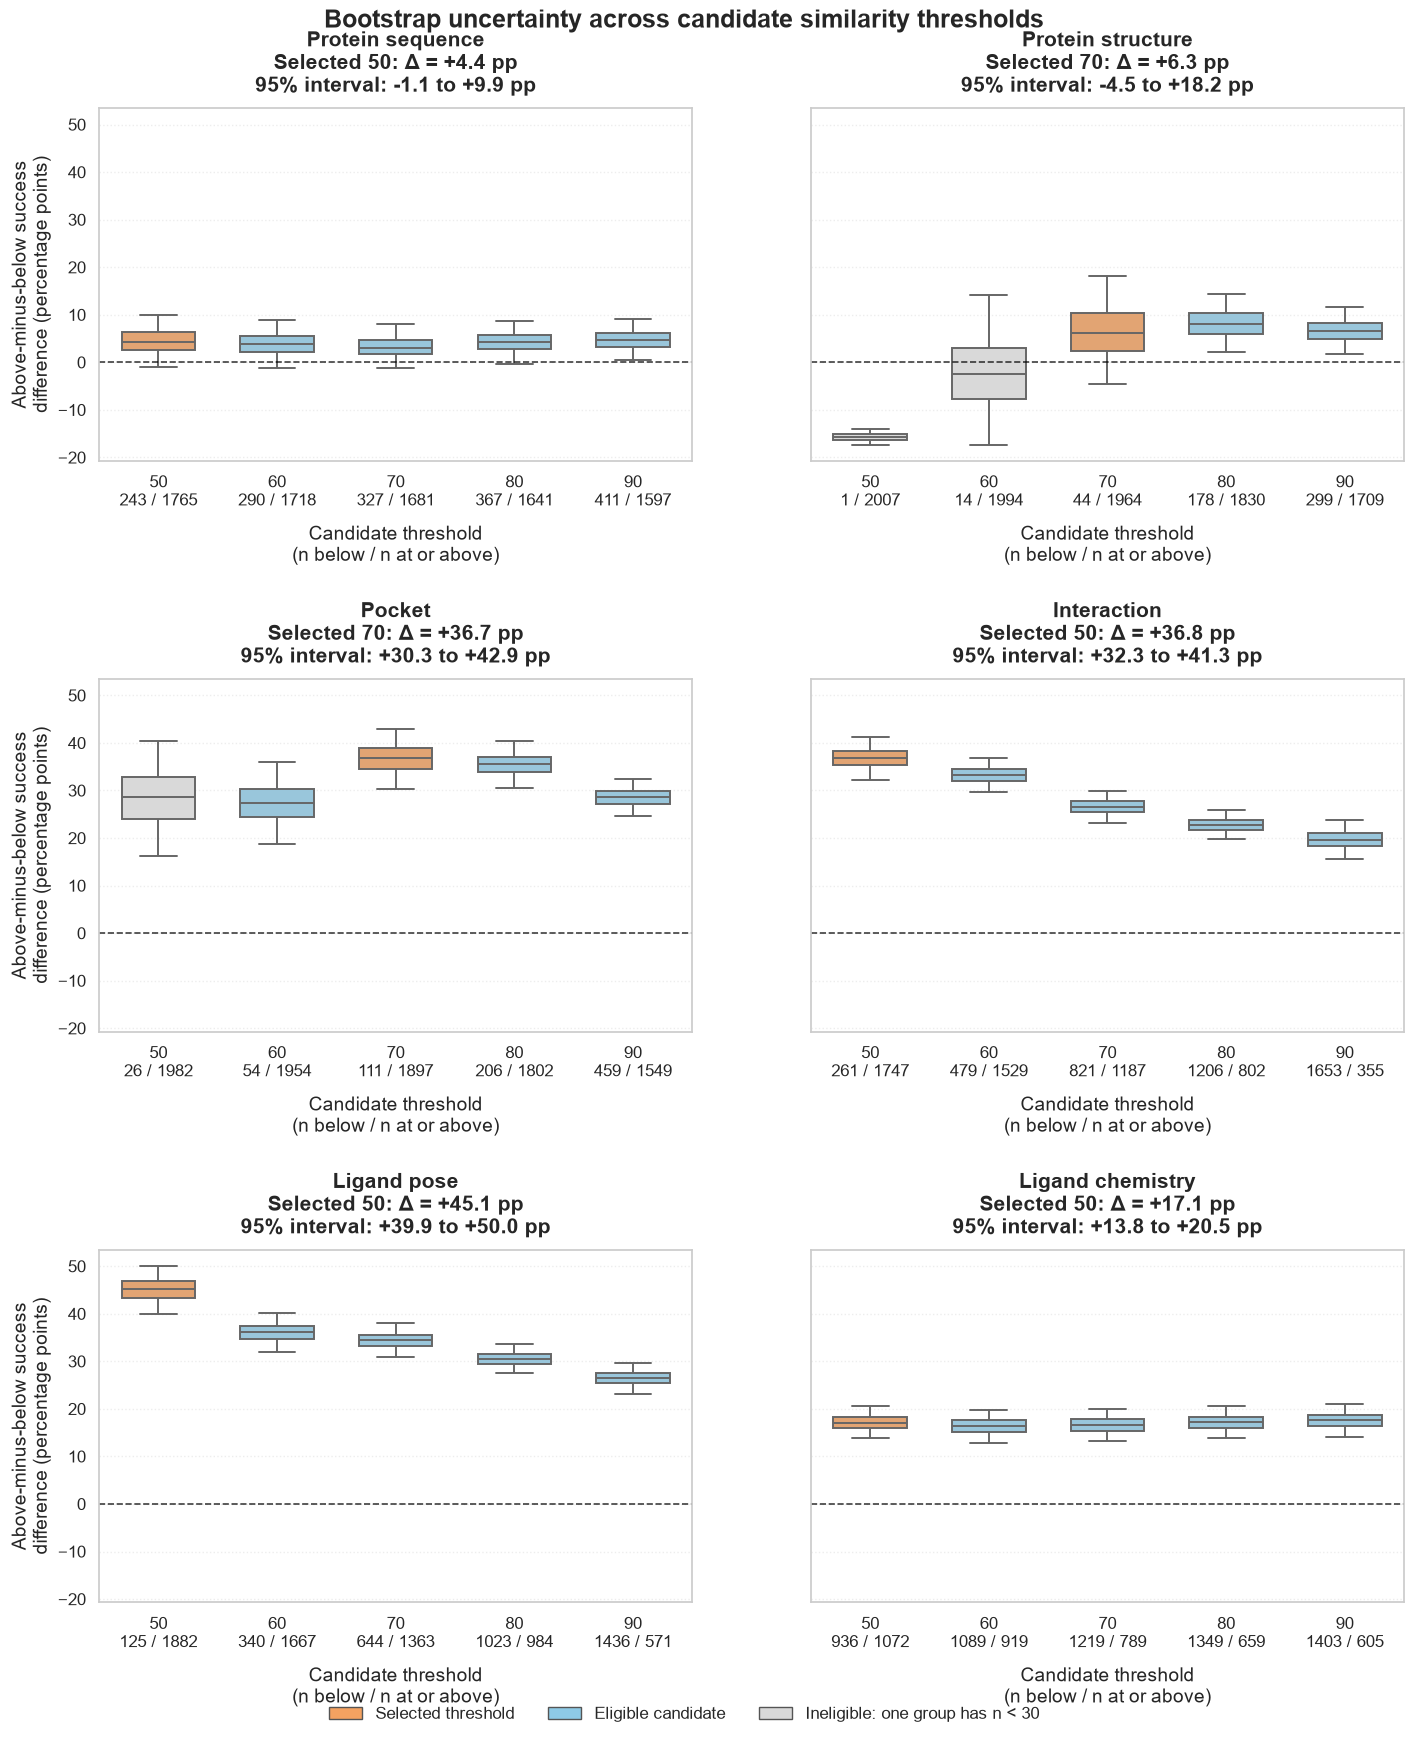

Saved PNG: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\candidate_threshold_bootstrap_thesis_A4.png
Saved PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\candidate_threshold_bootstrap_thesis_A4.pdf


In [15]:
from matplotlib.patches import Patch

metric_order = list(SIMILARITY_METRICS)

# Typography suitable for an A4 portrait page.
a4_style = {
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 18,
    "lines.linewidth": 1.5,
}

with plt.rc_context(a4_style):

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(15, 18),
        sharey=True,
    )

    for ax, metric_name in zip(axes.flat, metric_order):

        metric_bootstrap_df = bootstrap_threshold_effects_df.loc[
            bootstrap_threshold_effects_df[
                "similarity_metric"
            ].eq(metric_name)
        ].copy()

        metric_statistics = threshold_plot_values_df.loc[
            threshold_plot_values_df[
                "similarity_metric"
            ].eq(metric_name)
        ].copy()

        selected_threshold = SELECTED_THRESHOLDS[metric_name]

        threshold_order = [
            threshold
            for threshold in CANDIDATE_THRESHOLDS
            if threshold
            in set(metric_bootstrap_df["threshold"])
        ]

        threshold_palette = {}

        for threshold in threshold_order:

            row = metric_statistics.loc[
                metric_statistics["threshold"].eq(threshold)
            ]

            if row.empty:
                threshold_palette[threshold] = "#d9d9d9"
                continue

            row = row.iloc[0]

            if threshold == selected_threshold:
                threshold_palette[threshold] = "#f4a261"
            elif row["eligible_for_selection"]:
                threshold_palette[threshold] = "#8ecae6"
            else:
                threshold_palette[threshold] = "#d9d9d9"

        # Box = bootstrap IQR
        # Whiskers = central bootstrap 95% interval
        sns.boxplot(
            data=metric_bootstrap_df,
            x="threshold",
            y="delta_success_percent",
            order=threshold_order,
            hue="threshold",
            palette=threshold_palette,
            legend=False,
            showmeans=False,
            showfliers=False,
            whis=(2.5, 97.5),
            width=0.62,
            linewidth=1.4,
            ax=ax,
        )

        ax.axhline(
            0,
            color="black",
            linewidth=1.2,
            linestyle="--",
            alpha=0.75,
        )

        # Tick labels contain threshold and sample sizes.
        tick_labels = []

        for threshold in threshold_order:

            row = metric_statistics.loc[
                metric_statistics["threshold"].eq(threshold)
            ]

            if row.empty:
                tick_labels.append(f"{threshold:g}")
                continue

            row = row.iloc[0]

            tick_labels.append(
                f"{threshold:g}\n"
                f"{int(row['n_below'])} / "
                f"{int(row['n_above'])}"
            )

        ax.set_xticks(
            range(len(threshold_order)),
            labels=tick_labels,
        )

        selected_row = metric_statistics.loc[
            metric_statistics["threshold"].eq(
                selected_threshold
            )
        ]

        if not selected_row.empty:

            selected_row = selected_row.iloc[0]

            selected_delta = selected_row[
                "delta_success_percent"
            ]
            selected_lower = selected_row[
                "interval_lower_95_pp"
            ]
            selected_upper = selected_row[
                "interval_upper_95_pp"
            ]

            panel_title = (
                f"{metric_name}\n"
                f"Selected {selected_threshold:g}: "
                f"Δ = {selected_delta:+.1f} pp\n"
                f"95% interval: "
                f"{selected_lower:+.1f} to "
                f"{selected_upper:+.1f} pp"
            )

        else:
            panel_title = metric_name

        ax.set_title(
            panel_title,
            pad=12,
            fontweight="semibold",
        )

        ax.set_xlabel(
            "Candidate threshold\n"
            "(n below / n at or above)",
            labelpad=10,
        )

        ax.set_ylabel(
            (
                "Above-minus-below success\n"
                "difference (percentage points)"
                if ax.get_subplotspec().is_first_col()
                else ""
            )
        )

        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=1,
            alpha=0.35,
        )

    selection_legend = [
        Patch(
            facecolor="#f4a261",
            edgecolor="#555555",
            label="Selected threshold",
        ),
        Patch(
            facecolor="#8ecae6",
            edgecolor="#555555",
            label="Eligible candidate",
        ),
        Patch(
            facecolor="#d9d9d9",
            edgecolor="#555555",
            label="Ineligible: one group has n < 30",
        ),
    ]

    fig.legend(
        handles=selection_legend,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.025),
        ncol=3,
        frameon=False,
    )

    fig.suptitle(
        "Bootstrap uncertainty across candidate similarity thresholds",
        y=0.985,
        fontweight="semibold",
    )

    # Avoid tight_layout here because it can compress the large text.
    fig.subplots_adjust(
        left=0.11,
        right=0.98,
        bottom=0.10,
        top=0.93,
        hspace=0.62,
        wspace=0.20,
    )

    threshold_figure_path = (
        OUTPUT_DIR
        / "candidate_threshold_bootstrap_thesis_A4.png"
    )

    fig.savefig(
        threshold_figure_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    # Vector output is preferable for thesis text and line art.
    threshold_figure_pdf_path = (
        OUTPUT_DIR
        / "candidate_threshold_bootstrap_thesis_A4.pdf"
    )

    fig.savefig(
        threshold_figure_pdf_path,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

print("Saved PNG:", threshold_figure_path)
print("Saved PDF:", threshold_figure_pdf_path)

## Section 2 — Applying the thresholds to evaluate local training-set density

### Objective

For each metric, a training system is considered a neighbour when its similarity to the query is greater than or equal to the threshold selected in Section 1. Density is the number of qualifying neighbours associated with each query.

Queries are divided into three groups:

- **No neighbours:** density equals zero.
- **Low density:** positive density at or below the median positive density for that metric.
- **High density:** positive density above that median.

`build_density_query_table()` constructs the query-level density dataset. Similarity is divided into global quantiles shared by all density groups, allowing performance to be compared at similar similarity levels.

For each metric, two complementary figures are produced:

1. a line plot showing mean prediction success across similarity quantiles for each density group; and
2. a violin plot replacing the previous heatmap, showing the distribution of query-level success within each similarity-quantile and density combination. Internal quartile lines identify the median and interquartile range.


In [7]:
def build_density_query_table(
    sim_df,
    query_success_df,
    similarity_column,
    similarity_name,
    threshold,
):
    '''Construct query-level similarity, neighbour-count, and density data.'''

    metric_pairs = sim_df[["query_system", similarity_column]].copy()
    metric_pairs[similarity_column] = pd.to_numeric(
        metric_pairs[similarity_column], errors="coerce"
    )
    metric_pairs = metric_pairs.dropna(subset=[similarity_column])

    query_features = (
        metric_pairs
        .groupby("query_system")[similarity_column]
        .agg(
            best_similarity="max",
            density=lambda values: values.ge(threshold).sum(),
            mean_similarity_above_threshold=lambda values: (
                values.loc[values.ge(threshold)].mean()
            ),
        )
        .reset_index()
    )
    query_features["density"] = query_features["density"].astype(int)

    # For queries with neighbours, visualise their mean neighbour similarity.
    # For queries without neighbours, retain their maximum observed similarity.
    query_features["visualisation_similarity"] = query_features[
        "mean_similarity_above_threshold"
    ].fillna(query_features["best_similarity"])

    query_df = query_success_df.merge(
        query_features,
        on="query_system",
        how="inner",
        validate="one_to_one",
    )

    positive_density = query_df.loc[query_df["density"].gt(0), "density"]
    if positive_density.empty:
        raise ValueError(
            f"No positive-density queries for {similarity_name} at "
            f"threshold {threshold}."
        )

    positive_density_median = positive_density.median()
    low_density_maximum = int(np.floor(positive_density_median))
    high_density_minimum = low_density_maximum + 1
    maximum_density = int(positive_density.max())

    query_df["density_group"] = np.select(
        [
            query_df["density"].eq(0),
            query_df["density"].le(low_density_maximum),
        ],
        ["No neighbours", "Low density"],
        default="High density",
    )
    query_df["similarity_metric"] = similarity_name
    query_df["similarity_column"] = similarity_column
    query_df["threshold"] = threshold
    query_df["mean_success_percent"] = query_df["mean_success"] * 100

    density_labels = {
        "No neighbours": "No neighbours (0)",
        "Low density": f"Low density (1–{low_density_maximum})",
        "High density": (
            f"High density ({high_density_minimum}–{maximum_density})"
        ),
    }

    density_definition_df = pd.DataFrame({
        "density_group": ["No neighbours", "Low density", "High density"],
        "display_label": [
            density_labels["No neighbours"],
            density_labels["Low density"],
            density_labels["High density"],
        ],
        "minimum_density": [0, 1, high_density_minimum],
        "maximum_density": [0, low_density_maximum, maximum_density],
        "n_queries": [
            query_df["density_group"].eq("No neighbours").sum(),
            query_df["density_group"].eq("Low density").sum(),
            query_df["density_group"].eq("High density").sum(),
        ],
    })

    return query_df, density_labels, density_definition_df


def add_similarity_quantiles(query_df, n_quantiles=5):
    """
    Assign global similarity quantiles shared by all density groups.

    Quantiles are calculated before separating the density groups, ensuring
    that each density curve uses the same similarity intervals.
    """

    quantile_df = query_df.copy()

    quantile_df["similarity_quantile"] = pd.qcut(
        quantile_df["visualisation_similarity"],
        q=n_quantiles,
        duplicates="drop",
    )

    ordered_intervals = sorted(
        quantile_df["similarity_quantile"].dropna().unique(),
        key=lambda interval: interval.left,
    )

    interval_to_index = {
        interval: index
        for index, interval in enumerate(ordered_intervals)
    }

    interval_to_label = {
        interval: (
            f"Q{index + 1}\n"
            f"{interval.left:.1f}–{interval.right:.1f}"
        )
        for index, interval in enumerate(ordered_intervals)
    }

    quantile_df["similarity_quantile_index"] = (
        quantile_df["similarity_quantile"]
        .map(interval_to_index)
        .astype("Int64")
    )

    quantile_df["similarity_quantile_label"] = (
        quantile_df["similarity_quantile"]
        .map(interval_to_label)
    )

    quantile_order = [
        interval_to_label[interval]
        for interval in ordered_intervals
    ]

    return quantile_df, quantile_order


In [8]:
def summarise_similarity_curves(
    quantile_df,
    n_bootstrap=2000,
    random_seed=42,
):
    """
    Summarise success and obtain a query-level bootstrap 95% interval
    for every similarity-quantile and density-group combination.

    Intervals are pointwise rather than simultaneous confidence bands.
    """

    random_generator = np.random.default_rng(random_seed)
    summary_rows = []

    grouped = quantile_df.dropna(
        subset=[
            "similarity_quantile",
            "similarity_quantile_index",
            "similarity_quantile_label",
            "density_group",
            "mean_success",
        ]
    ).groupby(
        [
            "similarity_quantile",
            "similarity_quantile_index",
            "similarity_quantile_label",
            "density_group",
        ],
        observed=True,
    )

    for group_keys, group_df in grouped:

        (
            similarity_quantile,
            similarity_quantile_index,
            similarity_quantile_label,
            density_group,
        ) = group_keys

        # One success value per query/complex.
        success_values = (
            group_df
            .drop_duplicates("query_system")
            ["mean_success"]
            .astype(float)
            .to_numpy()
            * 100
        )

        n_queries = len(success_values)

        if n_queries == 0:
            continue

        mean_success_percent = success_values.mean()

        # Resample complete queries, preserving the query as the
        # independent statistical unit.
        bootstrap_means = np.empty(
            n_bootstrap,
            dtype=float,
        )

        for bootstrap_iteration in range(n_bootstrap):
            bootstrap_sample = random_generator.choice(
                success_values,
                size=n_queries,
                replace=True,
            )
            bootstrap_means[bootstrap_iteration] = (
                bootstrap_sample.mean()
            )

        summary_rows.append({
            "similarity_quantile": similarity_quantile,
            "similarity_quantile_index": int(
                similarity_quantile_index
            ),
            "similarity_quantile_label": (
                similarity_quantile_label
            ),
            "density_group": density_group,
            "mean_success_percent": mean_success_percent,
            "n_queries": n_queries,
            "bootstrap_standard_error_percent": (
                bootstrap_means.std(ddof=1)
            ),
            "confidence_lower_95_percent": np.quantile(
                bootstrap_means,
                0.025,
            ),
            "confidence_upper_95_percent": np.quantile(
                bootstrap_means,
                0.975,
            ),
        })

    curve_summary_df = pd.DataFrame(summary_rows)

    if not curve_summary_df.empty:
        curve_summary_df = curve_summary_df.sort_values(
            [
                "density_group",
                "similarity_quantile_index",
            ]
        ).reset_index(drop=True)

    return curve_summary_df

In [9]:
# Publication-style typography used by the density figures.
# Font sizes are intended for figures inserted into an A4 report.

DENSITY_PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "font.size": 9.5,
    "axes.titlesize": 12.5,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10.5,
    "axes.labelweight": "normal",
    "xtick.labelsize": 9.0,
    "ytick.labelsize": 9.0,
    "legend.fontsize": 8.8,
    "legend.title_fontsize": 9.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

In [12]:
def plot_density_figures(
    quantile_df,
    curve_summary_df,
    quantile_order,
    density_labels,
    similarity_name,
    threshold,
    output_dir,
):
    """
    Create:
    1. Mean-success line plots with query counts and pointwise
       query-bootstrap 95% confidence intervals.
    2. Query-level violin plots separated by similarity quantile
       and training-set density.

    Returns
    -------
    line_path : pathlib.Path
        Path to the PNG line plot.
    violin_path : pathlib.Path
        Path to the PNG violin plot.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    density_order = [
        "No neighbours",
        "Low density",
        "High density",
    ]

    colors = {
        "No neighbours": "#1f77b4",
        "Low density": "#f4a261",
        "High density": "#2a9d8f",
    }

    # Different offsets reduce overlap between sample-size labels.
    count_offsets = {
        "No neighbours": (-10, 11),
        "Low density": (0, -16),
        "High density": (10, 11),
    }

    safe_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        similarity_name.lower(),
    ).strip("_")

    # Apply the style only to the figures created by this function.
    with plt.rc_context(DENSITY_PLOT_STYLE):

        # ===========================================================
        # 1. Line plot with bootstrap confidence bands
        # ===========================================================

        fig, ax = plt.subplots(
            figsize=(7.2, 4.8)
        )

        for density_group in density_order:

            group_df = (
                curve_summary_df.loc[
                    curve_summary_df[
                        "density_group"
                    ].eq(density_group)
                ]
                .sort_values(
                    "similarity_quantile_index"
                )
            )

            if group_df.empty:
                continue

            x_values = (
                group_df[
                    "similarity_quantile_index"
                ]
                .astype(float)
                .to_numpy()
            )

            mean_values = (
                group_df[
                    "mean_success_percent"
                ]
                .astype(float)
                .to_numpy()
            )

            lower_values = (
                group_df[
                    "confidence_lower_95_percent"
                ]
                .astype(float)
                .to_numpy()
            )

            upper_values = (
                group_df[
                    "confidence_upper_95_percent"
                ]
                .astype(float)
                .to_numpy()
            )

            color = colors[density_group]

            # Pointwise query-bootstrap 95% confidence interval.
            ax.fill_between(
                x_values,
                lower_values,
                upper_values,
                color=color,
                alpha=0.16,
                linewidth=0,
                zorder=1,
            )

            # Mean success curve.
            ax.plot(
                x_values,
                mean_values,
                color=color,
                marker="o",
                markersize=5.5,
                markeredgewidth=0,
                linewidth=1.8,
                label=density_labels.get(
                    density_group,
                    density_group,
                ),
                zorder=3,
            )

            # Number of unique complexes contributing to each point.
            x_offset, y_offset = (
                count_offsets[density_group]
            )

            for row in group_df.itertuples(
                index=False
            ):
                ax.annotate(
                    f"n={int(row.n_queries)}",
                    xy=(
                        float(
                            row.similarity_quantile_index
                        ),
                        float(
                            row.mean_success_percent
                        ),
                    ),
                    xytext=(
                        x_offset,
                        y_offset,
                    ),
                    textcoords="offset points",
                    ha="center",
                    va="center",
                    fontsize=7.8,
                    fontweight="normal",
                    color=color,
                    bbox={
                        "boxstyle": "round,pad=0.12",
                        "facecolor": "white",
                        "edgecolor": "none",
                        "alpha": 0.70,
                    },
                    zorder=4,
                )

        ax.set_xticks(
            range(len(quantile_order))
        )

        ax.set_xticklabels(
            quantile_order
        )

        ax.set_xlabel(
            f"{similarity_name} quantile\n"
            f"Neighbour threshold ≥ {threshold}",
            labelpad=8,
        )

        ax.set_ylabel(
            "Mean prediction success across methods (%)",
            labelpad=8,
        )

        ax.set_title(
            f"{similarity_name}: prediction success across "
            "similarity\nand training-set density",
            pad=11,
        )

        ax.set_ylim(-5, 105)

        # Simplify the plot frame.
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_color(
            "#444444"
        )
        ax.spines["bottom"].set_color(
            "#444444"
        )

        ax.tick_params(
            axis="both",
            colors="#333333",
            direction="out",
        )

        ax.grid(
            axis="y",
            linestyle="-",
            linewidth=0.55,
            color="#d9d9d9",
            alpha=0.70,
            zorder=0,
        )

        legend = ax.legend(
            title="Training-set density",
            frameon=False,
            loc="upper left",
            borderaxespad=0.4,
            handlelength=2.0,
            handletextpad=0.6,
            labelspacing=0.4,
        )

        if legend is not None:
            legend._legend_box.align = "left"

        # Explanation of the confidence bands.
        ax.text(
            0.01,
            0.015,
            (
                "Shading indicates pointwise "
                "query-bootstrap 95% CIs"
            ),
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7.5,
            color="#666666",
        )

        fig.tight_layout()

        line_path = (
            output_dir
            / (
                f"{safe_name}_density_lines_"
                "with_bootstrap_ci.png"
            )
        )

        line_pdf_path = (
            output_dir
            / (
                f"{safe_name}_density_lines_"
                "with_bootstrap_ci.pdf"
            )
        )

        fig.savefig(
            line_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        fig.savefig(
            line_pdf_path,
            bbox_inches="tight",
            facecolor="white",
        )

        plt.show()
        plt.close(fig)

        # ===========================================================
        # 2. Query-level violin plot
        # ===========================================================

        fig, ax = plt.subplots(
            figsize=(8.2, 4.8)
        )

        sns.violinplot(
            data=quantile_df,
            x="similarity_quantile_label",
            y="mean_success_percent",
            order=quantile_order,
            hue="density_group",
            hue_order=density_order,
            palette=colors,
            inner="quartile",
            cut=0,
            density_norm="width",
            common_norm=False,
            dodge=True,
            linewidth=0.8,
            saturation=0.85,
            ax=ax,
        )

        ax.set_xlabel(
            f"{similarity_name} quantile\n"
            f"Neighbour threshold ≥ {threshold}",
            labelpad=8,
        )

        ax.set_ylabel(
            "Query-level mean prediction success (%)",
            labelpad=8,
        )

        ax.set_title(
            f"{similarity_name}: query-level success "
            "distributions\nacross similarity and "
            "training-set density",
            pad=11,
        )

        ax.set_ylim(-5, 105)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_color(
            "#444444"
        )
        ax.spines["bottom"].set_color(
            "#444444"
        )

        ax.tick_params(
            axis="both",
            colors="#333333",
            direction="out",
        )

        ax.grid(
            axis="y",
            linestyle="-",
            linewidth=0.55,
            color="#d9d9d9",
            alpha=0.70,
            zorder=0,
        )

        handles, labels = (
            ax.get_legend_handles_labels()
        )

        legend = ax.legend(
            handles,
            [
                density_labels.get(
                    label,
                    label,
                )
                for label in labels
            ],
            title="Training-set density",
            frameon=False,
            bbox_to_anchor=(1.01, 1),
            loc="upper left",
            borderaxespad=0,
            handletextpad=0.6,
            labelspacing=0.4,
        )

        if legend is not None:
            legend._legend_box.align = "left"

        fig.tight_layout()

        violin_path = (
            output_dir
            / f"{safe_name}_density_violins.png"
        )

        violin_pdf_path = (
            output_dir
            / f"{safe_name}_density_violins.pdf"
        )

        fig.savefig(
            violin_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        fig.savefig(
            violin_pdf_path,
            bbox_inches="tight",
            facecolor="white",
        )

        plt.show()
        plt.close(fig)

    print("Saved line plot:", line_path)
    print("Saved line PDF:", line_pdf_path)
    print("Saved violin plot:", violin_path)
    print("Saved violin PDF:", violin_pdf_path)

    return line_path, violin_path


Protein sequence: neighbour threshold ≥ 50


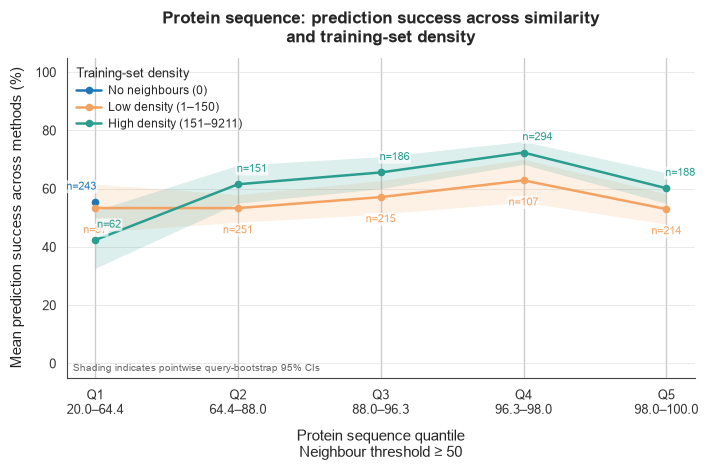

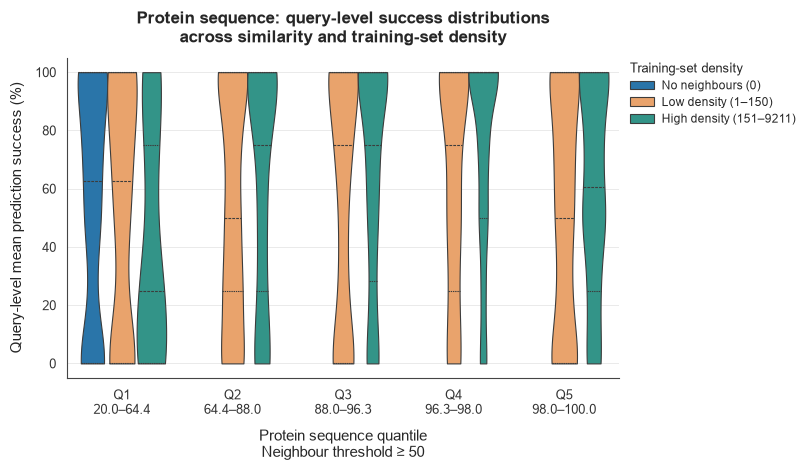

Saved line plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_sequence_density_lines_with_bootstrap_ci.png
Saved line PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_sequence_density_lines_with_bootstrap_ci.pdf
Saved violin plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_sequence_density_violins.png
Saved violin PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_sequence_density_violins.pdf


,density_group,display_label,minimum_density,maximum_density,n_queries
0,No neighbours,No neighbours (0),0,0,243
1,Low density,Low density (1–150),1,150,884
2,High density,High density (151–9211),151,9211,881



Protein structure: neighbour threshold ≥ 70


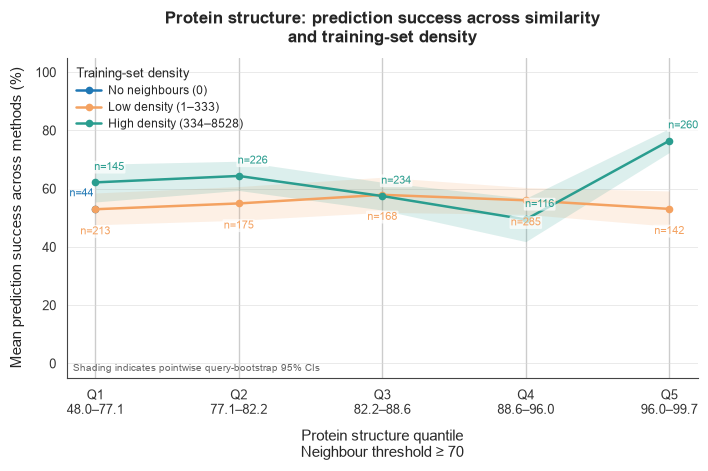

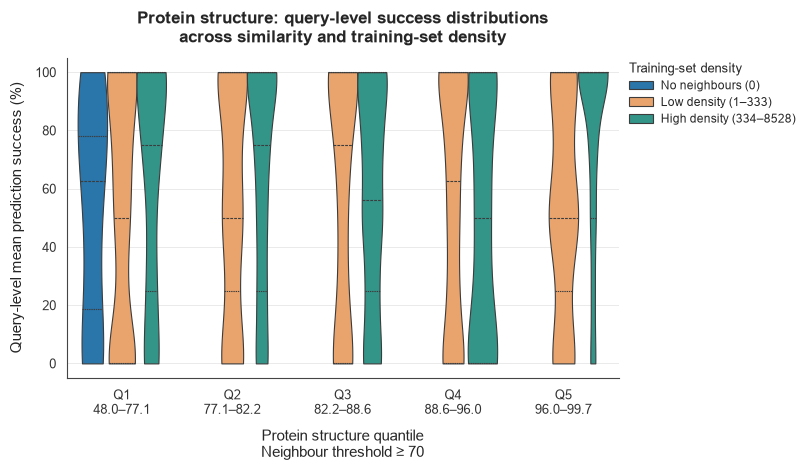

Saved line plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_structure_density_lines_with_bootstrap_ci.png
Saved line PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_structure_density_lines_with_bootstrap_ci.pdf
Saved violin plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_structure_density_violins.png
Saved violin PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\protein_structure_density_violins.pdf


,density_group,display_label,minimum_density,maximum_density,n_queries
0,No neighbours,No neighbours (0),0,0,44
1,Low density,Low density (1–333),1,333,983
2,High density,High density (334–8528),334,8528,981



Pocket: neighbour threshold ≥ 70


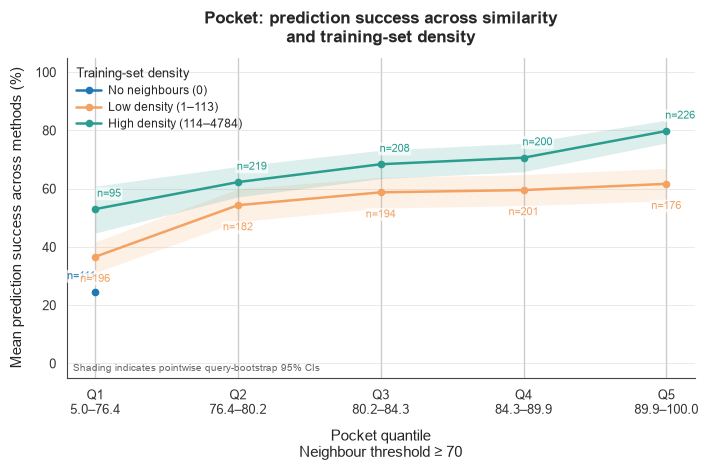

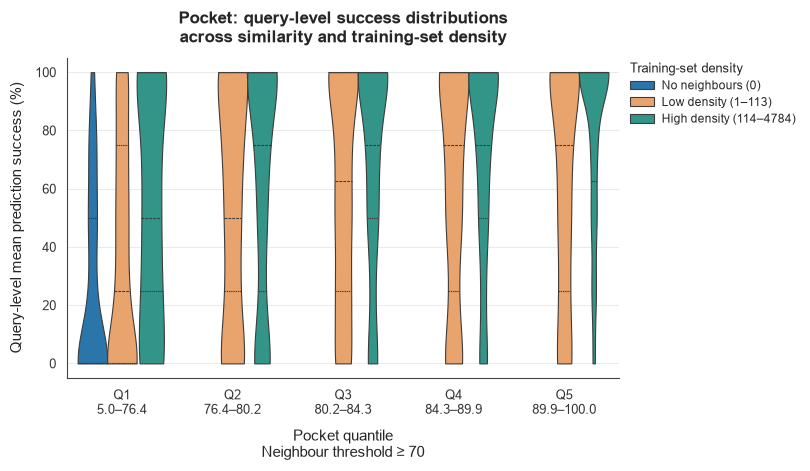

Saved line plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\pocket_density_lines_with_bootstrap_ci.png
Saved line PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\pocket_density_lines_with_bootstrap_ci.pdf
Saved violin plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\pocket_density_violins.png
Saved violin PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\pocket_density_violins.pdf


,density_group,display_label,minimum_density,maximum_density,n_queries
0,No neighbours,No neighbours (0),0,0,111
1,Low density,Low density (1–113),1,113,949
2,High density,High density (114–4784),114,4784,948



Interaction: neighbour threshold ≥ 50


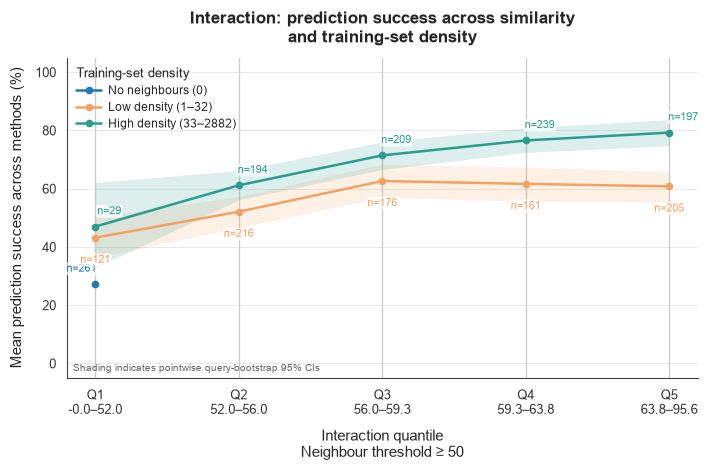

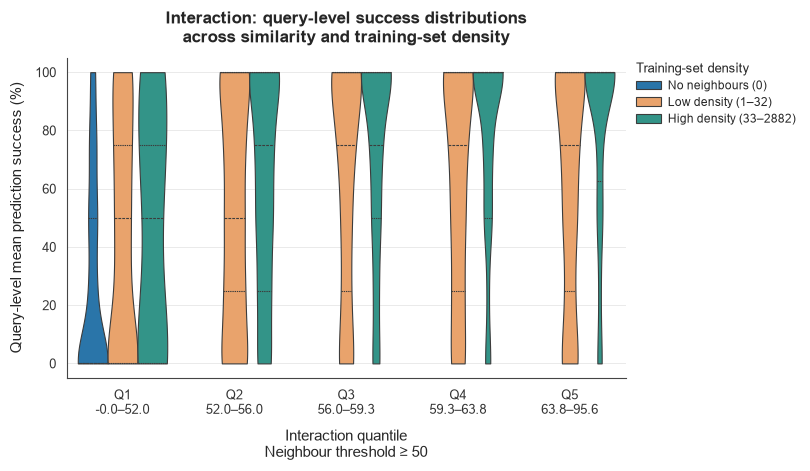

Saved line plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\interaction_density_lines_with_bootstrap_ci.png
Saved line PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\interaction_density_lines_with_bootstrap_ci.pdf
Saved violin plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\interaction_density_violins.png
Saved violin PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\interaction_density_violins.pdf


,density_group,display_label,minimum_density,maximum_density,n_queries
0,No neighbours,No neighbours (0),0,0,261
1,Low density,Low density (1–32),1,32,879
2,High density,High density (33–2882),33,2882,868



Ligand pose: neighbour threshold ≥ 50


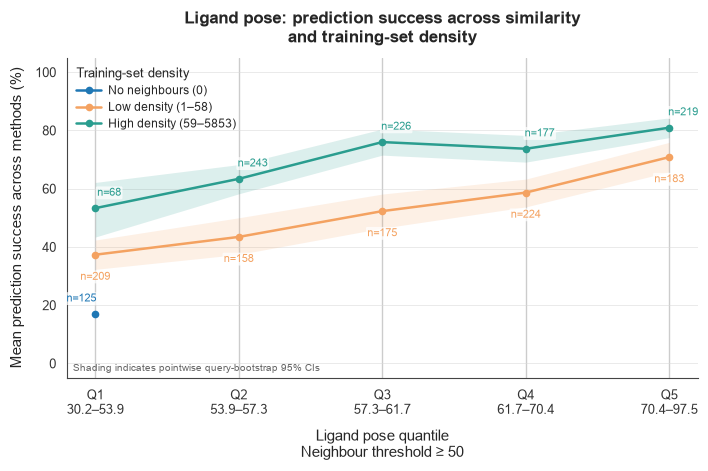

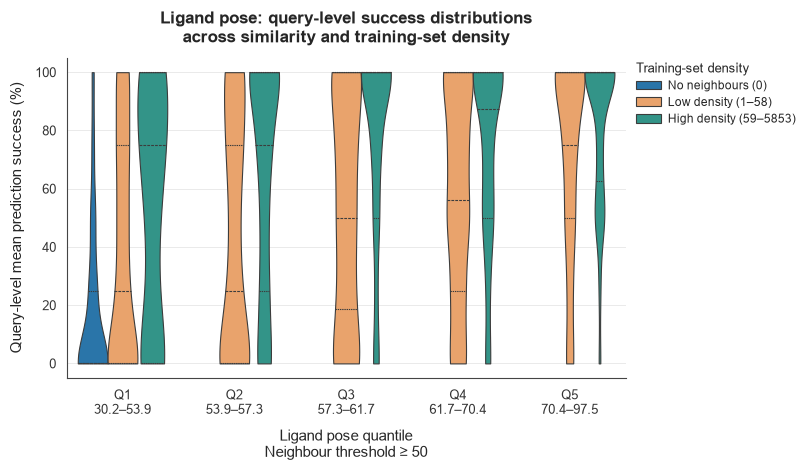

Saved line plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_pose_density_lines_with_bootstrap_ci.png
Saved line PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_pose_density_lines_with_bootstrap_ci.pdf
Saved violin plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_pose_density_violins.png
Saved violin PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_pose_density_violins.pdf


,density_group,display_label,minimum_density,maximum_density,n_queries
0,No neighbours,No neighbours (0),0,0,125
1,Low density,Low density (1–58),1,58,949
2,High density,High density (59–5853),59,5853,933



Ligand chemistry: neighbour threshold ≥ 50


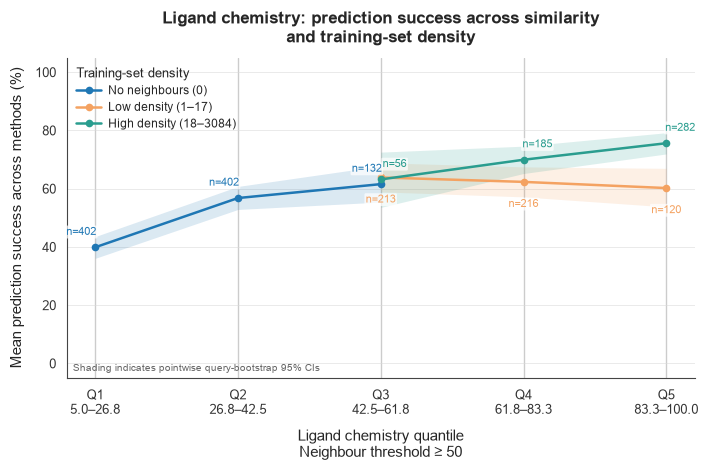

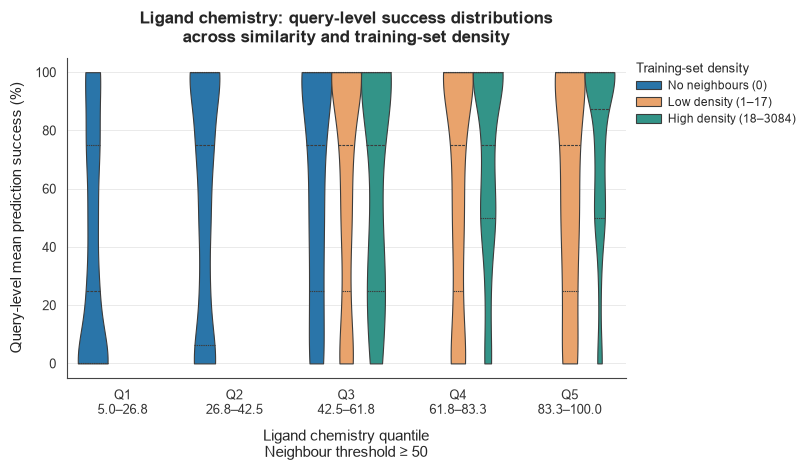

Saved line plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_chemistry_density_lines_with_bootstrap_ci.png
Saved line PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_chemistry_density_lines_with_bootstrap_ci.pdf
Saved violin plot: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_chemistry_density_violins.png
Saved violin PDF: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis\ligand_chemistry_density_violins.pdf


,density_group,display_label,minimum_density,maximum_density,n_queries
0,No neighbours,No neighbours (0),0,0,936
1,Low density,Low density (1–17),1,17,549
2,High density,High density (18–3084),18,3084,523


In [13]:
def run_density_analysis(
    sim_df,
    query_success_df,
    similarity_metrics,
    selected_thresholds,
    n_quantiles=5,
    output_dir=OUTPUT_DIR,
):
    '''Run the complete density analysis for all selected metrics.'''

    density_results = {}

    for similarity_name, similarity_column in similarity_metrics.items():
        threshold = selected_thresholds[similarity_name]
        print(f"\n{similarity_name}: neighbour threshold ≥ {threshold}")

        query_df, density_labels, density_definition_df = (
            build_density_query_table(
                sim_df=sim_df,
                query_success_df=query_success_df,
                similarity_column=similarity_column,
                similarity_name=similarity_name,
                threshold=threshold,
            )
        )
        quantile_df, quantile_order = add_similarity_quantiles(
            query_df,
            n_quantiles=n_quantiles,
        )
        curve_summary_df = summarise_similarity_curves(
            quantile_df,
            n_bootstrap=2000,
            random_seed=42,
        )
        line_path, violin_path = plot_density_figures(
            quantile_df=quantile_df,
            curve_summary_df=curve_summary_df,
            quantile_order=quantile_order,
            density_labels=density_labels,
            similarity_name=similarity_name,
            threshold=threshold,
            output_dir=output_dir,
        )

        display(density_definition_df)
        density_results[similarity_name] = {
            "query_table": query_df,
            "density_definition": density_definition_df,
            "curve_summary": curve_summary_df,
            "line_figure": line_path,
            "violin_figure": violin_path,
        }

    return density_results


density_analysis_results = run_density_analysis(
    sim_df=analysis_similarity_pairs_df,
    query_success_df=query_success_df,
    similarity_metrics=SIMILARITY_METRICS,
    selected_thresholds=SELECTED_THRESHOLDS,
)


In [10]:
# Save the main numerical outputs for auditing and subsequent reporting.
threshold_effects_df.to_csv(
    OUTPUT_DIR / "candidate_threshold_effects.csv",
    index=False,
)
selected_thresholds_df.to_csv(
    OUTPUT_DIR / "selected_similarity_thresholds.csv",
    index=False,
)
bootstrap_threshold_summary_df.to_csv(
    OUTPUT_DIR / "selected_threshold_bootstrap_summary.csv",
    index=False,
)

for similarity_name, metric_results in density_analysis_results.items():
    safe_name = re.sub(
        r"[^A-Za-z0-9]+", "_", similarity_name.lower()
    ).strip("_")
    metric_results["query_table"].to_csv(
        OUTPUT_DIR / f"{safe_name}_density_query_table.csv",
        index=False,
    )
    metric_results["curve_summary"].to_csv(
        OUTPUT_DIR / f"{safe_name}_density_curve_summary.csv",
        index=False,
    )

print("All tables and figures were saved to:", OUTPUT_DIR)


All tables and figures were saved to: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\threshold_density_analysis
